# Logistic Balanced Class for All Failure Labels

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
DATA_PATH = Path("data/ai4i2020.csv")
TARGET_COLUMNS = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
DROP_COLUMNS = ["UID", "Product ID"]
MODEL_OPTIONS = {"logreg_c_0.1": 0.1, "logreg_c_1.0": 1.0, "logreg_c_10.0": 10.0}
RANDOM_STATE = 42
TEST_SIZE = 0.2

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=DROP_COLUMNS + TARGET_COLUMNS)
y = df[TARGET_COLUMNS]

cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y["Machine failure"])

print(f"Dataset: {df.shape}, Train: {X_train.shape}, Test: {X_test.shape}")


Dataset: (10000, 14), Train: (8000, 6), Test: (2000, 6)


In [18]:
def get_balanced_indices(y, target_col, neg_ratio=5, random_state=42):
    pos_idx = y.index[y[target_col] == 1]
    neg_idx = y.index[y[target_col] == 0]
    if len(pos_idx) == 0: return y.index
    neg_sample = y.loc[neg_idx].sample(n=min(len(neg_idx), neg_ratio * len(pos_idx)), random_state=random_state).index
    return pos_idx.union(neg_sample).sort_values()

def create_model(c_val):
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_features), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])
    clf = OneVsRestClassifier(LogisticRegression(C=c_val, class_weight="balanced", max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
    return Pipeline([("preprocessor", preprocessor), ("classifier", clf)])


In [19]:
model_metrics = []
model_predictions = {}

for model_name, c_val in MODEL_OPTIONS.items():
    model = create_model(c_val)
    model.fit(X_train, y_train)
    pred_df = pd.DataFrame(model.predict(X_test), columns=TARGET_COLUMNS, index=y_test.index)
    model_predictions[model_name] = pred_df

    for target in TARGET_COLUMNS:
        model_metrics.append({
            "model": model_name, "target": target,
            "precision": precision_score(y_test[target], pred_df[target], zero_division=0),
            "recall": recall_score(y_test[target], pred_df[target], zero_division=0),
            "f1": f1_score(y_test[target], pred_df[target], zero_division=0)
        })

metrics_df = pd.DataFrame(model_metrics)
metrics_df


,model,target,precision,recall,f1
0,logreg_c_0.1,Machine failure,0.138191,0.808824,0.236052
1,logreg_c_0.1,TWF,0.035294,0.900000,0.067925
2,logreg_c_0.1,HDF,0.204225,1.000000,0.339181
3,logreg_c_0.1,PWF,0.220339,1.000000,0.361111
4,logreg_c_0.1,OSF,0.150943,1.000000,0.262295
5,logreg_c_0.1,RNF,0.004594,0.750000,0.009132
6,logreg_c_1.0,Machine failure,0.141414,0.823529,0.241379
7,logreg_c_1.0,TWF,0.046154,0.900000,0.087805
8,logreg_c_1.0,HDF,0.292929,1.000000,0.453125
9,logreg_c_1.0,PWF,0.282609,1.000000,0.440678


In [20]:
model_summary = metrics_df.groupby("model")[["precision", "recall", "f1"]].mean().sort_values("f1", ascending=False)
model_summary


,precision,recall,f1
model,,,
logreg_c_10.0,0.215092,0.895588,0.323006
logreg_c_1.0,0.172400,0.912255,0.275540
logreg_c_0.1,0.125598,0.909804,0.212616


In [21]:
best_model = model_summary.index[0]
best_predictions = model_predictions[best_model]

print(f"Best model: {best_model}")
best_predictions.head()


Best model: logreg_c_10.0


,Machine failure,TWF,HDF,PWF,OSF,RNF
2997,1,0,0,1,0,1
4871,1,0,0,0,0,1
3858,1,1,0,0,0,1
951,0,0,0,0,0,0
6463,1,0,0,0,0,1


In [22]:
metrics_df[metrics_df["model"] == best_model].drop("model", axis=1).reset_index(drop=True)


,target,precision,recall,f1
0,Machine failure,0.142494,0.823529,0.242950
1,TWF,0.044693,0.800000,0.084656
2,HDF,0.337209,1.000000,0.504348
3,PWF,0.317073,1.000000,0.481481
4,OSF,0.444444,1.000000,0.615385
5,RNF,0.004637,0.750000,0.009217


In [23]:
print(f"Classification reports for {best_model}:\n")
for target in TARGET_COLUMNS:
    y_true = y_test[target]
    y_pred = model_predictions[best_model][target]
    print(f"{target}:\n{classification_report(y_true, y_pred, zero_division=0)}")


Classification reports for logreg_c_10.0:

Machine failure:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.83      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.83      0.88      2000

TWF:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1990
           1       0.04      0.80      0.08        10

    accuracy                           0.91      2000
   macro avg       0.52      0.86      0.52      2000
weighted avg       0.99      0.91      0.95      2000

HDF:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1971
           1       0.34      1.00      0.50        29

    accuracy                           0.97      2000
   macro avg       0.67      0.99      0.74      2000
weig

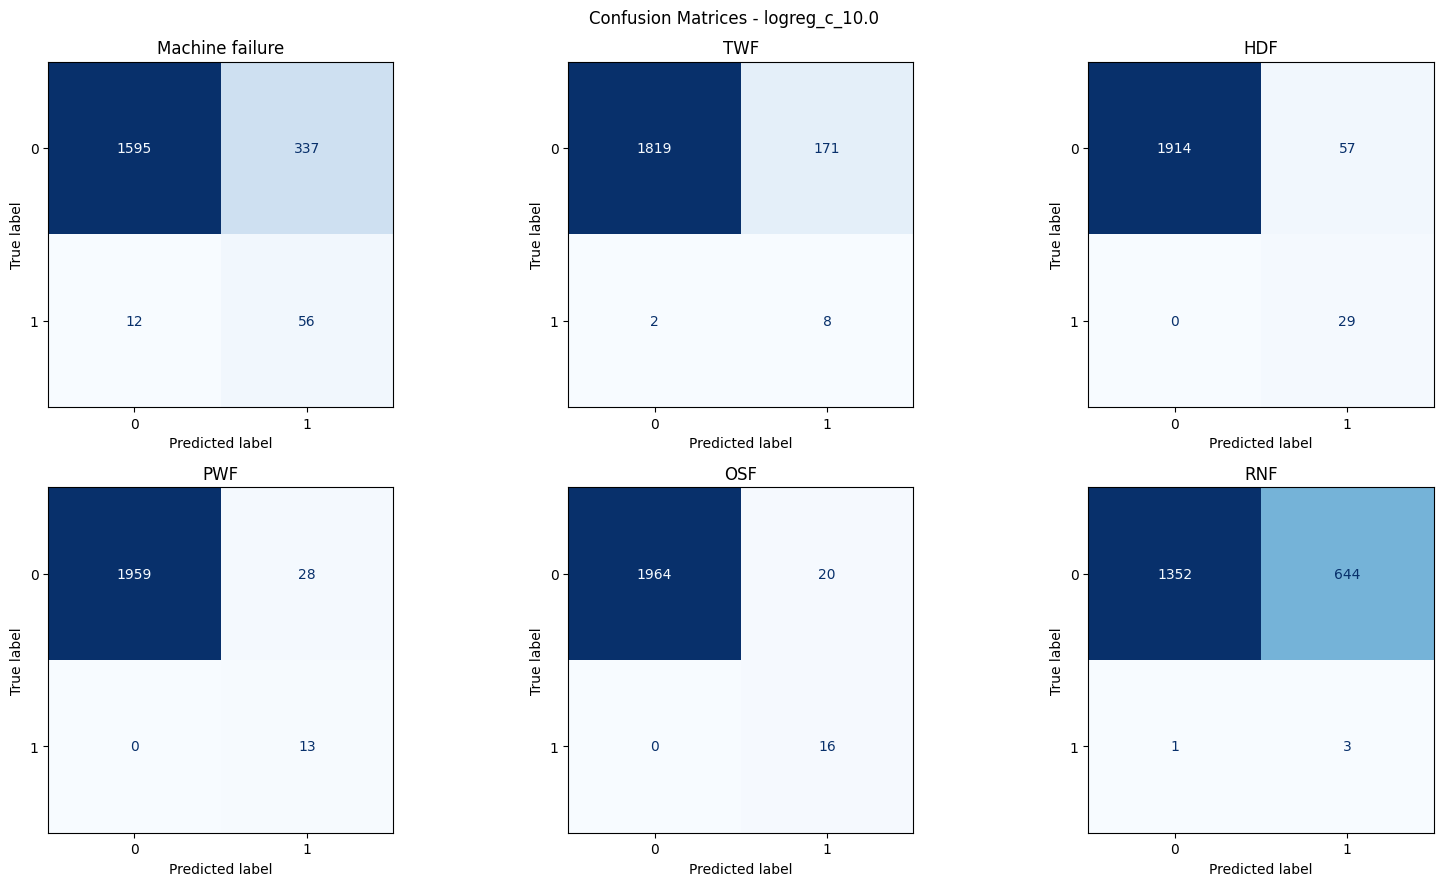

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, target in enumerate(TARGET_COLUMNS):
    y_true = y_test[target]
    y_pred = model_predictions[best_model][target]
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=[0, 1], cmap="Blues", colorbar=False, ax=axes.flat[i])
    axes.flat[i].set_title(target)
plt.suptitle(f"Confusion Matrices - {best_model}")
plt.tight_layout()
plt.show()


In [24]:
# Evaluation complete - models trained on full training set and evaluated on full test set